In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
# Let's change the sex, smoker, and region columns into numerical data

In [ ]:
# Sex
df["sex"] = df["sex"].map({"female": 0, "male": 1})

In [ ]:
# 0 = female, 1 = male
df["sex"].value_counts()

sex
1    676
0    662
Name: count, dtype: int64

In [ ]:
# smoker
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

In [ ]:
# 0 = not a smoker, 1 = smoker
df["smoker"].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [ ]:
# region - One Hot Encoding
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [ ]:
df = pd.get_dummies(df, columns=["region"], drop_first=True).astype(int)

In [ ]:
df.describe()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.169656,1.094918,0.204783,13269.928999,0.242900,0.272048,0.242900
std,14.049960,0.500160,6.119875,1.205493,0.403694,12110.012755,0.428995,0.445181,0.428995
min,18.000000,0.000000,15.000000,0.000000,0.000000,1121.000000,0.000000,0.000000,0.000000
25%,27.000000,0.000000,26.000000,0.000000,0.000000,4740.000000,0.000000,0.000000,0.000000
50%,39.000000,1.000000,30.000000,1.000000,0.000000,9381.500000,0.000000,0.000000,0.000000
75%,51.000000,1.000000,34.000000,2.000000,0.000000,16639.250000,0.000000,1.000000,0.000000
max,64.000000,1.000000,53.000000,5.000000,1.000000,63770.000000,1.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1338 non-null   int64
 1   sex               1338 non-null   int64
 2   bmi               1338 non-null   int64
 3   children          1338 non-null   int64
 4   smoker            1338 non-null   int64
 5   charges           1338 non-null   int64
 6   region_northwest  1338 non-null   int64
 7   region_southeast  1338 non-null   int64
 8   region_southwest  1338 non-null   int64
dtypes: int64(9)
memory usage: 94.2 KB


In [ ]:
'''Converted categorical variables (sex, smoker) to numerical format with mapping, and one-hot encoded the region column. These steps are required for regression models, which need numeric input. Confirmed value counts to check for balanced classes and that encoding completed as expected.'''

'Converted categorical variables (sex, smoker) to numerical format with mapping, and one-hot encoded the region column. These steps are required for regression models, which need numeric input. Confirmed value counts to check for balanced classes and that encoding completed as expected.'

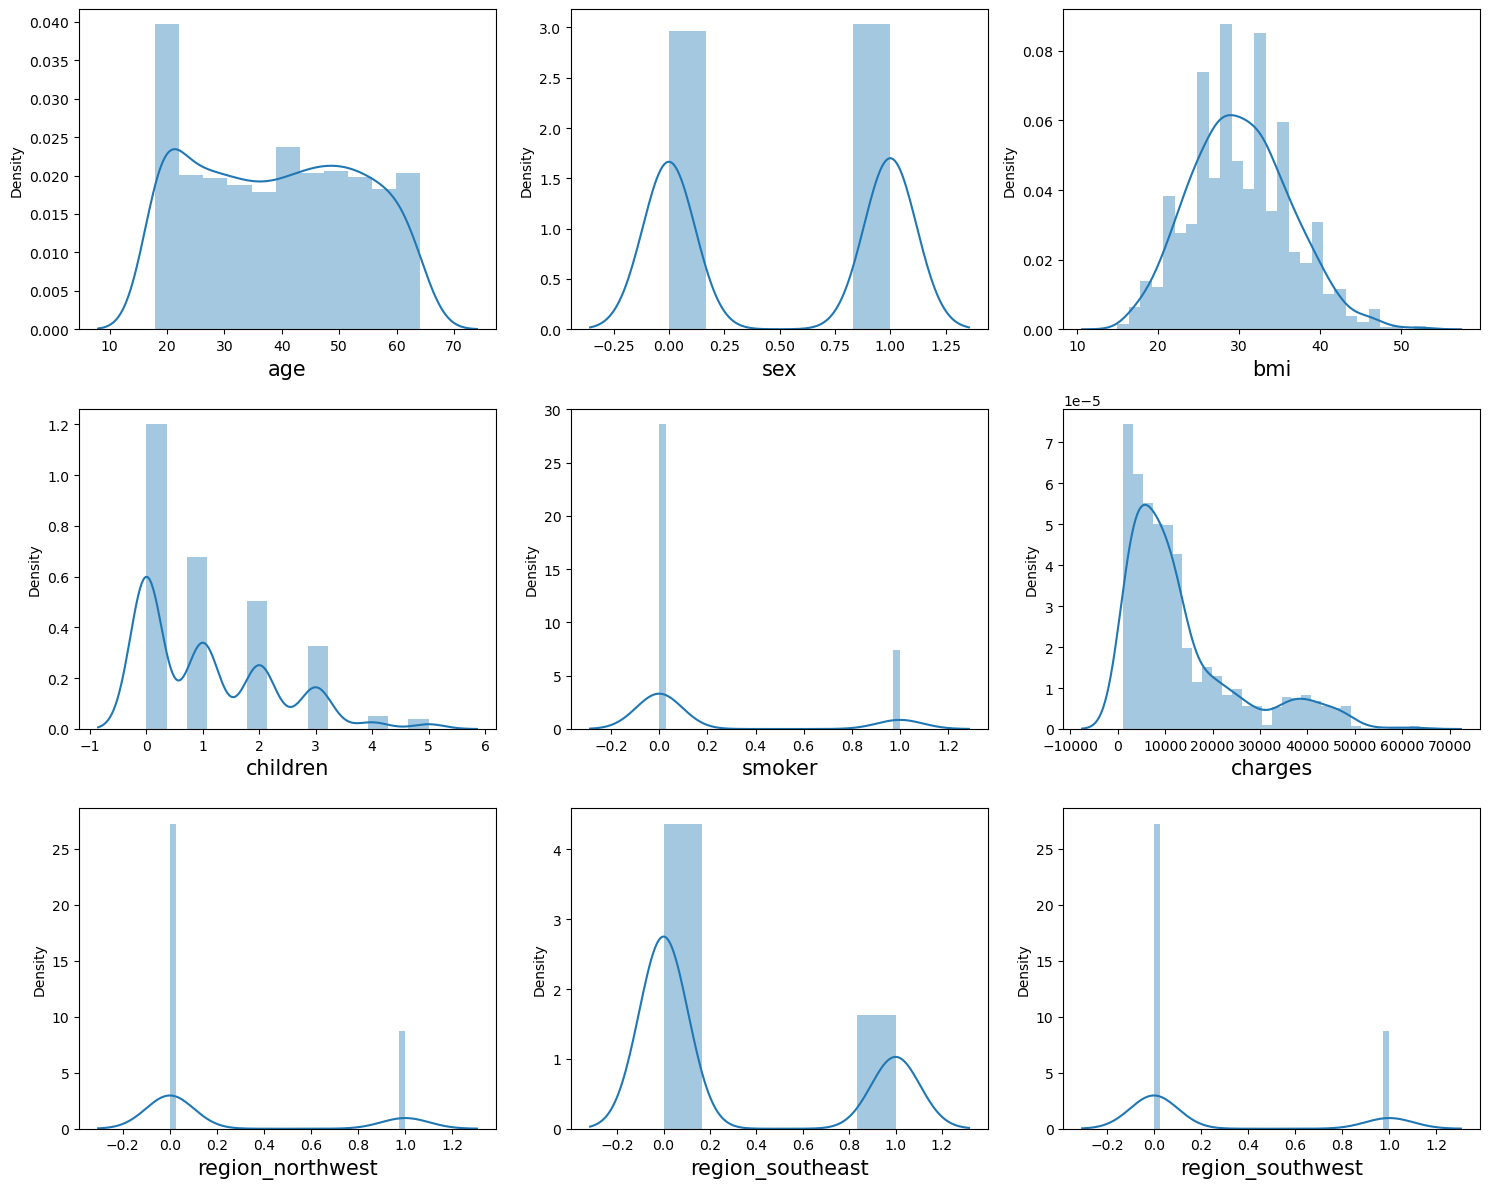

In [ ]:
plt.figure(figsize = (15,12))
plotnum = 1

for column in df:
    if plotnum <= 9:
        ax = plt.subplot(3, 3, plotnum)
        sns.distplot(df[column])
        plt.xlabel(column, fontsize = 15)

    plotnum += 1

plt.tight_layout()
plt.show()

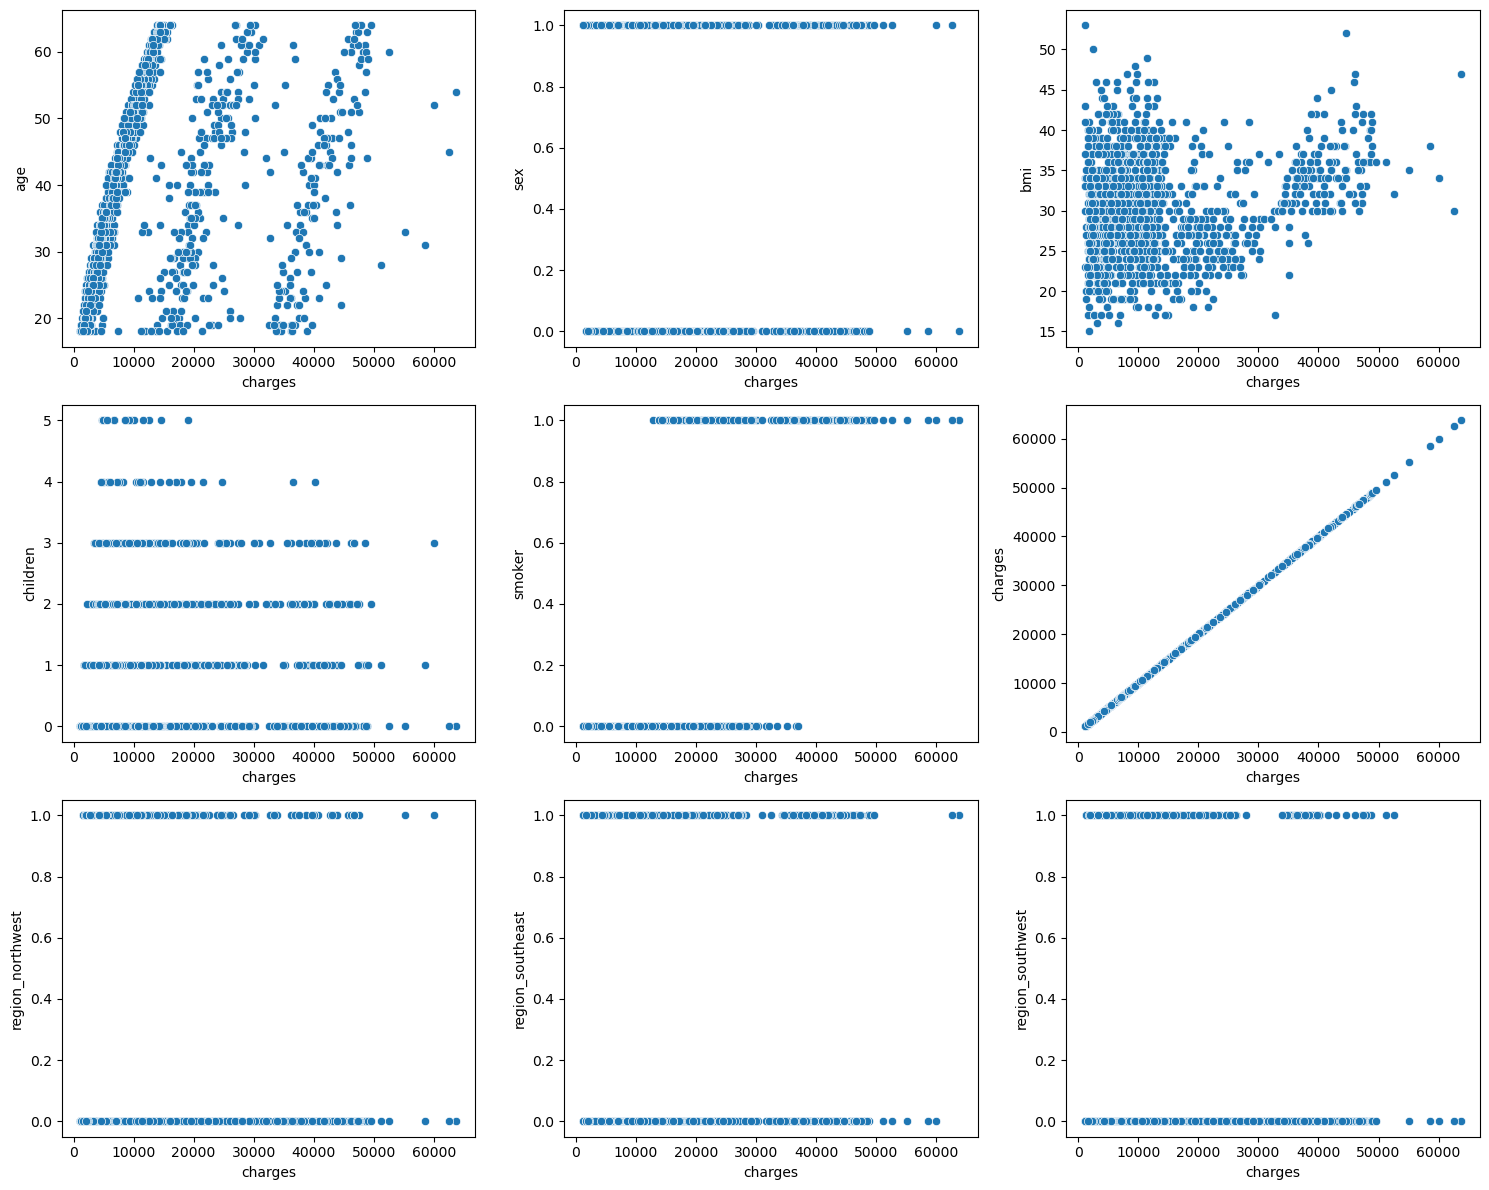

In [ ]:
# Plotting charges with the other columns

plt.figure(figsize = (15,12))
plotnum = 1

for column in df:
    if plotnum <= 9:
        ax = plt.subplot(3, 3, plotnum)
        sns.scatterplot(x = df["charges"], y = df[column])

    plotnum += 1

plt.tight_layout()
plt.show()

In [ ]:
'''Plotted distributions of key variables, which is important for spotting skewness, outliers, or potential need for transformations. The scatter plots relating each feature to charges provide visual hints about possible relationships. Average charge seem to decrease as number of children increase.'''

'Plotted distributions of key variables, which is important for spotting skewness, outliers, or potential need for transformations. The scatter plots relating each feature to charges provide visual hints about possible relationships. Average charge seem to decrease as number of children increase.'

In [ ]:
'''The scatter plot of age versus charges reveals that insurance costs increase progressively with age, with data points migrating through three main ranges: $0–15,000, $10,000–30,000, and $30,000–50,000. While charges are tightly grouped at lower range, the spread widens in the medium and high ranges. This suggests that although age contributes significantly to rising charges, other factors interact with age to create more variability among older individuals, such as number of children, smoking, and region. Understanding which factors drive movement into higher charge ranges will be a key part of later modeling.'''

'The scatter plot of age versus charges reveals that insurance costs increase progressively with age, with data points migrating through three main ranges: $0–15,000, $10,000–30,000, and $30,000–50,000. While charges are tightly grouped at lower range, the spread widens in the medium and high ranges. This suggests that although age contributes significantly to rising charges, other factors interact with age to create more variability among older individuals, such as number of children, smoking, and region. Understanding which factors drive movement into higher charge ranges will be a key part of later modeling.'

In [ ]:
# Regression
X = df.drop(columns = "charges", axis = 1)
y = df["charges"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.43876426, -1.0105187 , -0.51812191, ..., -0.56641788,
        -0.61132367,  1.76548098],
       [-1.50996545,  0.98959079,  0.46265684, ..., -0.56641788,
         1.63579466, -0.56641788],
       [-0.79795355,  0.98959079,  0.46265684, ..., -0.56641788,
         1.63579466, -0.56641788],
       ...,
       [-1.50996545, -1.0105187 ,  0.95304622, ..., -0.56641788,
         1.63579466, -0.56641788],
       [-1.29636188, -1.0105187 , -0.84504816, ..., -0.56641788,
        -0.61132367,  1.76548098],
       [ 1.55168573, -1.0105187 , -0.19119566, ...,  1.76548098,
        -0.61132367, -0.56641788]], shape=(1338, 8))

In [ ]:
'''Used StandardScaler to standardize features. This is useful when comparing feature importance or applying regularization methods, as it puts all predictors on the same scale.'''

'Used StandardScaler to standardize features. This is useful when comparing feature importance or applying regularization methods, as it puts all predictors on the same scale.'

In [ ]:
# checking for multicollinearity using `VIF`
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif["Features"] = X.columns

vif
# none of the columns seem to be heavily correlated with one another

,VIF,Features
0,1.016636,age
1,1.008930,sex
2,1.107868,bmi
3,1.003971,children
4,1.012149,smoker
5,1.518821,region_northwest
6,1.653430,region_southeast
7,1.529859,region_southwest


In [ ]:
'''Calculated Variance Inflation Factor (VIF) scores to check for multicollinearity among predictors. VIFs close to 1 indicate that the features are not highly correlated, so you we safely use them in regression without worrying about instability in the estimated coefficients.'''

'Calculated Variance Inflation Factor (VIF) scores to check for multicollinearity among predictors. VIFs close to 1 indicate that the features are not highly correlated, so you we safely use them in regression without worrying about instability in the estimated coefficients.'

In [ ]:
# splitting data into training and test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state = 0)

In [ ]:
# fitting the training data into model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [ ]:
# prediction of model
y_predicted = lr.predict(X_test)

In [ ]:
# training accuracy of model -R^2
lr.score(X_train, y_train)

0.7310765658725603

In [ ]:
# test accuracy of model -R^2
lr.score(X_test, y_test)

0.7905851590983884

In [ ]:
# creating a function to create adjusted R-Squared

def adj_r2(X, y, model):
    r2 = model.score(X, y)
    n = X.shape[0]
    p = X.shape[1]
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    return adjusted_r2

In [ ]:
print(adj_r2(X_train, y_train, lr))

0.7287557595370484


In [ ]:
print(adj_r2(X_test, y_test, lr))

0.7863222615736737


In [ ]:
from sklearn.feature_selection import f_regression
feature_indices = [0, 2, 4]
features = ["age", "bmi", "smoker"]

In [ ]:
X_features = X_train[:, feature_indices]

f_stats, p_values = f_regression(X_features, y_train)
feature_importance = pd.DataFrame({
    "Feature": features,
    "P-value": p_values
}).sort_values("P-value")
print(feature_importance)

  Feature        P-value
2  smoker  9.831220e-185
0     age   3.025059e-18
1     bmi   4.346584e-08


In [ ]:
'''An F-test was conducted to determine which factors significantly influence medical insurance charges. This approach evaluates the statistical significance of the relationship between age, smoking status, and BMI, with the charges outcome. The procedure generates a p-value for each feature, which provides evidence of whether its association with charges is likely to reflect an actual effect within the data rather than random variation. The analysis found that each feature produced an extremely small p-value, all well below the standard significance threshold of 0.05. Such results indicate that age, smoking status, and BMI are highly significant predictors of insurance costs in the dataset. Among these features, smoking status exhibited the lowest p-value, which highlights it as the most influential predictor.'''

'An F-test was conducted to determine which factors significantly influence medical insurance charges. This approach evaluates the statistical significance of the relationship between age, smoking status, and BMI, with the charges outcome. The procedure generates a p-value for each feature, which provides evidence of whether its association with charges is likely to reflect an actual effect within the data rather than random variation. The analysis found that each feature produced an extremely small p-value, all well below the standard significance threshold of 0.05. Such results indicate that age, smoking status, and BMI are highly significant predictors of insurance costs in the dataset. Among these features, smoking status exhibited the lowest p-value, which highlights it as the most influential predictor.'

In [ ]:
# Let's add the rest of the columns into the features
feature_indices = [0, 1, 2, 3, 4, 5, 6, 7]
features = ["age", "sex", "bmi", "children", "smoker", "region_northwest", "region_southeast", "region_southwest"]

In [ ]:
X_features = X_train[:, feature_indices]

f_stats, p_values = f_regression(X_features, y_train)
feature_importance = pd.DataFrame({
    "Feature": features,
    "P-value": p_values
}).sort_values("P-value")
print(feature_importance)

            Feature        P-value
4            smoker  9.831220e-185
0               age   3.025059e-18
2               bmi   4.346584e-08
6  region_southeast   6.010482e-03
3          children   1.836582e-02
7  region_southwest   2.764666e-02
1               sex   1.280704e-01
5  region_northwest   2.266294e-01


In [ ]:
'''This updated F-test analysis now includes all the columns in the regression model. Results show that smoker status, age, and BMI continue to have the smallest p-values, meaning they are the most statistically significant predictors of insurance charges. The region variables also have p-values below 0.05 in some cases, which indicates statistical significance, but their p-values are larger than those for the main demographic and health features. Having a p-value under 0.05 means the relationship between that region and insurance costs is unlikely to be due to random chance. However, the stronger statistical association of smoking, age, and BMI highlights that these factors have a much greater influence on insurance charges than regional variables or other features included in the analysis.'''

'This updated F-test analysis now includes all the columns in the regression model. Results show that smoker status, age, and BMI continue to have the smallest p-values, meaning they are the most statistically significant predictors of insurance charges. The region variables also have p-values below 0.05 in some cases, which indicates statistical significance, but their p-values are larger than those for the main demographic and health features. Having a p-value under 0.05 means the relationship between that region and insurance costs is unlikely to be due to random chance. However, the stronger statistical association of smoking, age, and BMI highlights that these factors have a much greater influence on insurance charges than regional variables or other features included in the analysis.'

In [ ]:
# Let's calculate feature importance
features = ["age", "sex", "bmi", "children", "smoker", "region_northwest", "region_southeast", "region_southwest"]

coefs = lr.coef_

importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefs,
    "AbsValue": abs(coefs)
}).sort_values("AbsValue", ascending=False)
print(importance_df[["Feature", "Coefficient"]])

            Feature  Coefficient
4            smoker  9463.836661
0               age  3603.267140
2               bmi  2050.053670
3          children   575.677431
6  region_southeast  -450.721653
7  region_southwest  -347.095170
5  region_northwest  -239.884581
1               sex   -22.709637


In [ ]:
'''The regression coefficients show that smoking status has the largest positive effect on insurance charges, with smokers paying on average over 9,460 units more than non-smokers, holding all other variables constant. Age and BMI also have strong positive relationships, indicating that each additional year of age or point increase in BMI is associated with higher charges. Having more children modestly increases charges, while being in the southeast, southwest, or northwest regions slightly decreases predicted charges compared to the baseline region. Sex has a very small negative effect, suggesting minimal impact. Overall, smoking status, age, and BMI are the most influential predictors in this model, with region and sex exerting much less effect on insurance costs.'''

'The regression coefficients show that smoking status has the largest positive effect on insurance charges, with smokers paying on average over 9,460 units more than non-smokers, holding all other variables constant. Age and BMI also have strong positive relationships, indicating that each additional year of age or point increase in BMI is associated with higher charges. Having more children modestly increases charges, while being in the southeast, southwest, or northwest regions slightly decreases predicted charges compared to the baseline region. Sex has a very small negative effect, suggesting minimal impact. Overall, smoking status, age, and BMI are the most influential predictors in this model, with region and sex exerting much less effect on insurance costs.'

In [ ]:
y_predicted = lr.predict(X_test)

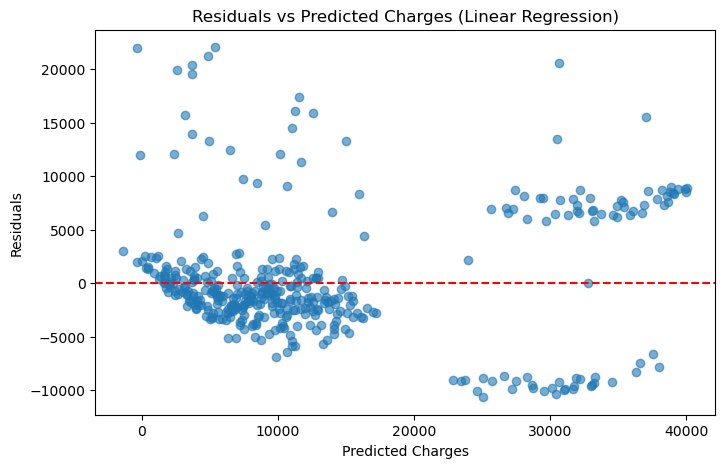

In [ ]:
residuals = y_test - y_predicted

plt.figure(figsize=(8,5))
plt.scatter(y_predicted, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Charges (Linear Regression)")
plt.show()

In [ ]:
'''The residual plot for the linear regression model displays a curved and widening pattern, where prediction errors grow larger as the predicted charges increase. This indicates that the linear model struggles to capture nonlinear relationships present in the data, particularly those associated with smokers and individuals with higher BMI values. In many cases, the model underestimates insurance charges at higher cost values, reflecting its inability to model the cost increases tied to certain health and lifestyle factors. Additionally, the spread of residuals increases with predicted charges, suggesting heteroscedasticity and reinforcing that a simple linear form is insufficient for modeling real insurance cost behavior. These patterns signal the need for a more flexible modeling approach capable of capturing nonlinear effects and variable interactions, motivating the transition to a polynomial regression model.'''

'The residual plot for the linear regression model displays a curved and widening pattern, where prediction errors grow larger as the predicted charges increase. This indicates that the linear model struggles to capture nonlinear relationships present in the data, particularly those associated with smokers and individuals with higher BMI values. In many cases, the model underestimates insurance charges at higher cost values, reflecting its inability to model the cost increases tied to certain health and lifestyle factors. Additionally, the spread of residuals increases with predicted charges, suggesting heteroscedasticity and reinforcing that a simple linear form is insufficient for modeling real insurance cost behavior. These patterns signal the need for a more flexible modeling approach capable of capturing nonlinear effects and variable interactions, motivating the transition to a polynomial regression model.'

In [ ]:
# Expanding features to include all pairwise interactions so the model can capture combined effects such as age x smoker or bmi x region.
X = df.drop(columns="charges")
y = df["charges"]

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Using polynomial features to model potential non linear relationships
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

In [ ]:
lr_poly = LinearRegression()
lr_poly.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import r2_score

y_train_pred = lr_poly.predict(X_train)
y_test_pred = lr_poly.predict(X_test)

In [ ]:
# Calculate R^2 for training data
r2_score(y_train, y_train_pred)

0.8304819651982145

In [ ]:
# Calculate R^2 for testing data
r2_score(y_test, y_test_pred)

0.8693604123289449

In [ ]:
# Adjusted R^2 for training data
adj_r2(X_train, y_train, lr_poly)

0.8236937012906903

In [ ]:
# Adjusted R^2 for testing data
adj_r2(X_test, y_test, lr_poly)

0.8564754119011149

In [ ]:
feature_names = poly.get_feature_names_out(X.columns)

In [ ]:
coeffs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_poly.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

# Show top 15 by magnitude
print(coeffs.head(15))

                              Feature  Coefficient
4                              smoker  9659.104844
0                                 age  3824.557380
22                         bmi smoker  3632.560260
2                                 bmi  2036.759867
3                            children   668.438829
24               bmi region_southeast  -562.496444
13               age region_southeast   380.540408
25               bmi region_southwest  -378.384908
14               age region_southwest   354.364427
29          children region_southwest  -323.678925
35  region_southeast region_southwest   312.964421
18               sex region_northwest   306.085467
19               sex region_southeast   305.160020
12               age region_northwest   288.498872
7                    region_southwest  -280.431644


In [ ]:
'''After adding all pairwise interaction terms, the polynomial model highlighted that smoking, age, and BMI remain the dominant factors of insurance charges. Interactions reveal additional nuances, such as higher BMI increased charges even more for smokers (bmi × smoker) and regional differences slightly modifying the effects of age, BMI, and children. Overall, while the main predictors explain most variability, interactions improve interpretability and capture subtle cost patterns in specific subgroups.'''

'After adding all pairwise interaction terms, the polynomial model highlighted that smoking, age, and BMI remain the dominant factors of insurance charges. Interactions reveal additional nuances, such as higher BMI increased charges even more for smokers (bmi × smoker) and regional differences slightly modifying the effects of age, BMI, and children. Overall, while the main predictors explain most variability, interactions improve interpretability and capture subtle cost patterns in specific subgroups.'

In [ ]:
model_results = [
    {"Model": "Linear Regression", "Train R²": 0.731, "Test R²": 0.791, "Train Adj R²": 0.729, "Test Adj R²": 0.786},
    {"Model": "Polynomial Regression", "Train R²": 0.830, "Test R²": 0.869, "Train Adj R²": 0.824, "Test Adj R²": 0.856}]

comparison_df = pd.DataFrame(model_results)
print(comparison_df)

                   Model  Train R²  Test R²  Train Adj R²  Test Adj R²
0      Linear Regression     0.731    0.791         0.729        0.786
1  Polynomial Regression     0.830    0.869         0.824        0.856


In [ ]:
'''Adding polynomial interaction terms significantly improved model performance, with training R^2 increasing from 0.731 to 0.830 and testing R^2 from 0.791 to 0.869, while adjusted R^2 similarly increased. This indicates that interactions between features, particularly BMI x smoker, capture meaningful combined effects that a simple linear model misses. Despite these improvements, smoking status, age, BMI, and to a lesser extent number of children remain the primary drivers of insurance charges, consistent with the original linear model. Interestingly, several region-based interactions, such as age x region and BMI x region, appear among the next most influential features, suggesting that geographic factors subtly modify the effect of other predictors.'''

'Adding polynomial interaction terms significantly improved model performance, with training R^2 increasing from 0.731 to 0.830 and testing R^2 from 0.791 to 0.869, while adjusted R^2 similarly increased. This indicates that interactions between features, particularly BMI x smoker, capture meaningful combined effects that a simple linear model misses. Despite these improvements, smoking status, age, BMI, and to a lesser extent number of children remain the primary drivers of insurance charges, consistent with the original linear model. Interestingly, several region-based interactions, such as age x region and BMI x region, appear among the next most influential features, suggesting that geographic factors subtly modify the effect of other predictors.'

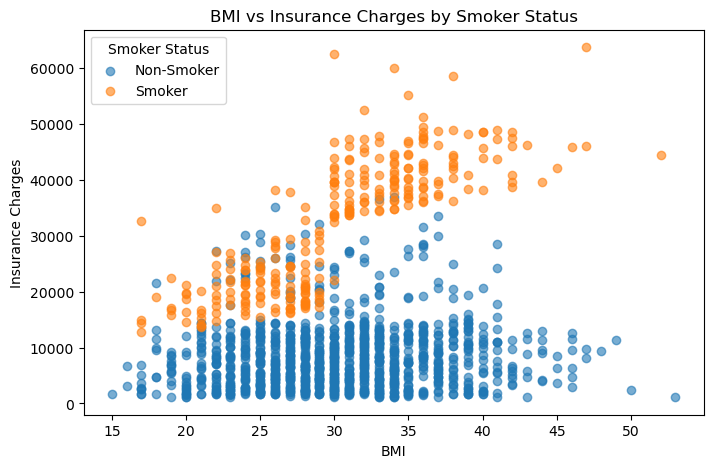

In [ ]:
plt.figure(figsize=(8,5))

non_smokers = df[df["smoker"] == 0]
smokers = df[df["smoker"] == 1]

plt.scatter(non_smokers["bmi"], non_smokers["charges"], alpha=0.6, label="Non-Smoker")
plt.scatter(smokers["bmi"], smokers["charges"], alpha=0.6, label="Smoker")

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges by Smoker Status")
plt.legend(title="Smoker Status")

plt.show()

In [ ]:
'''The scatter plot shows the relationship between BMI and insurance charges, separated by smoker status. The orange points represent smokers, and the blue points represent non smokers. The graph makes it clear that smokers tend to have much higher insurance charges than non smokers for the same BMI, and the difference becomes even more evident at higher BMI values. For non smokers, insurance charges generally increase with BMI but stay within a moderate range. In contrast, charges for smokers are consistently higher and rise sharply with increasing BMI. This visual evidence supports the previous statistical analysis, confirming that both smoking status and BMI have strong and combined effects on insurance costs.'''

'The scatter plot shows the relationship between BMI and insurance charges, separated by smoker status. The orange points represent smokers, and the blue points represent non smokers. The graph makes it clear that smokers tend to have much higher insurance charges than non smokers for the same BMI, and the difference becomes even more evident at higher BMI values. For non smokers, insurance charges generally increase with BMI but stay within a moderate range. In contrast, charges for smokers are consistently higher and rise sharply with increasing BMI. This visual evidence supports the previous statistical analysis, confirming that both smoking status and BMI have strong and combined effects on insurance costs.'

In [ ]:
y_predicted = lr_poly.predict(X_test)

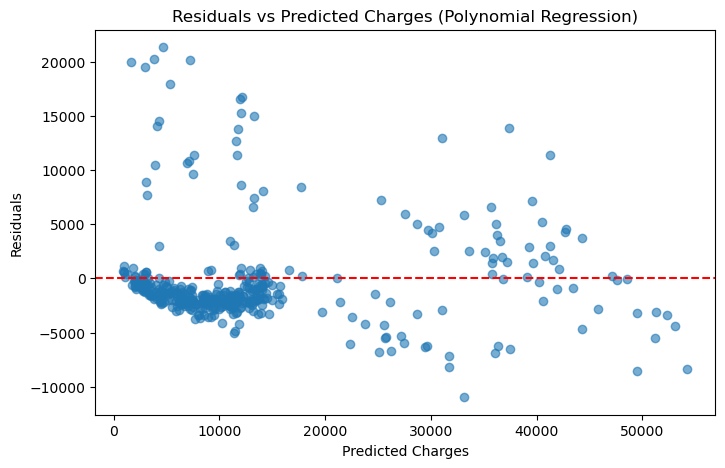

In [ ]:
residuals = y_test - y_predicted

plt.figure(figsize=(8,5))
plt.scatter(y_predicted, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Charges (Polynomial Regression)")
plt.show()

In [ ]:
'''The residual plot for the polynomial regression model shows that while the residuals are generally more centered around zero than in the linear model, noticeable patterns remain. In particular, there are several high residuals at the lower range of predicted charges, suggesting that some individuals who were expected to have relatively low costs actually incurred much higher charges. This may reflect cases where smokers or individuals with elevated BMI appear younger or otherwise “low risk” according to the base features, but in reality face sharply increased insurance costs that the polynomial model does not fully capture. At higher predicted charge levels, above roughly $20,000, the residuals also widen and become more dispersed, indicating that the model still struggles to predict the most expensive cases accurately. While the polynomial approach improves the model’s ability to capture nonlinear relationships compared to simple linear regression, the remaining structure in the residuals suggests that there are still important interactions or patterns the model cannot represent. I will next use a more flexible model to address these limitations and more effectively learn complex, nonlinear relationships.'''

'The residual plot for the polynomial regression model shows that while the residuals are generally more centered around zero than in the linear model, noticeable patterns remain. In particular, there are several high residuals at the lower range of predicted charges, suggesting that some individuals who were expected to have relatively low costs actually incurred much higher charges. This may reflect cases where smokers or individuals with elevated BMI appear younger or otherwise “low risk” according to the base features, but in reality face sharply increased insurance costs that the polynomial model does not fully capture. At higher predicted charge levels, above roughly $20,000, the residuals also widen and become more dispersed, indicating that the model still struggles to predict the most expensive cases accurately. While the polynomial approach improves the model’s ability to capture nonlinear relationships compared to simple linear regression, the remaining structure in the resi

In [ ]:
# Gradient Boosting can capture nonlinear relationships and more complex feature interactions
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01, min_samples_leaf=5, max_depth=3, random_state=0)

In [ ]:
# Fit the model on the training data
gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, min_samples_leaf=5,
                          n_estimators=1000, random_state=0)

In [ ]:
# Predict on train and test sets
y_train_pred_gbr = gbr.predict(X_train)
y_test_pred_gbr = gbr.predict(X_test)

In [ ]:
# Calculate training data R^2
r2_score(y_train, y_train_pred_gbr)

0.8999811368280479

In [ ]:
# Calculate testing data R^2
r2_score(y_test, y_test_pred_gbr)

0.8849968364036009

In [ ]:
'''After tuning the Gradient Boosting model, the training R^2 decreased from 0.94 to 0.90 while the test R^2 increased from 0.85 to 0.88, showing that the model now balances fitting the training data with generalizing to unseen data. This demonstrates reduced overfitting while still capturing complex interactions, such as BMI x smoker and age x smoker, which significantly influence insurance charges.'''

'After tuning the Gradient Boosting model, the training R^2 decreased from 0.94 to 0.90 while the test R^2 increased from 0.85 to 0.88, showing that the model now balances fitting the training data with generalizing to unseen data. This demonstrates reduced overfitting while still capturing complex interactions, such as BMI x smoker and age x smoker, which significantly influence insurance charges.'

In [ ]:
adj_r2(X_train, y_train, gbr)

0.895975932073665

In [ ]:
adj_r2(X_test, y_test, gbr)

0.8736540586242301

In [ ]:
feature_names = poly.get_feature_names_out(X.columns)

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gbr.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance.head(15))

                 Feature  Importance
4                 smoker    0.657788
22            bmi smoker    0.088230
2                    bmi    0.080197
0                    age    0.063774
11            age smoker    0.050278
10          age children    0.009633
9                age bmi    0.009539
25  bmi region_southwest    0.005181
13  age region_southeast    0.004951
23  bmi region_northwest    0.004308
15               sex bmi    0.003819
12  age region_northwest    0.003628
21          bmi children    0.003578
24  bmi region_southeast    0.002699
16          sex children    0.001790


In [ ]:
'''Gradient Boosting confirms that smoking status dominates insurance charges, with an importance of 0.658, which is far higher than any other feature. Interactions such as bmi x smoker (0.088) and age x smoker (0.050) further highlight that high BMI and older smokers face disproportionately higher costs. Age and BMI alone remain important (0.064 and 0.080, respectively), while other interactions, including age x children and regional effects, contribute modestly. This illustrates that while multiple factors influence charges, smoker status is by far the most critical predictor, and capturing its nonlinear interactions with BMI and age significantly improves model performance.'''

'Gradient Boosting confirms that smoking status dominates insurance charges, with an importance of 0.658, which is far higher than any other feature. Interactions such as bmi x smoker (0.088) and age x smoker (0.050) further highlight that high BMI and older smokers face disproportionately higher costs. Age and BMI alone remain important (0.064 and 0.080, respectively), while other interactions, including age x children and regional effects, contribute modestly. This illustrates that while multiple factors influence charges, smoker status is by far the most critical predictor, and capturing its nonlinear interactions with BMI and age significantly improves model performance.'

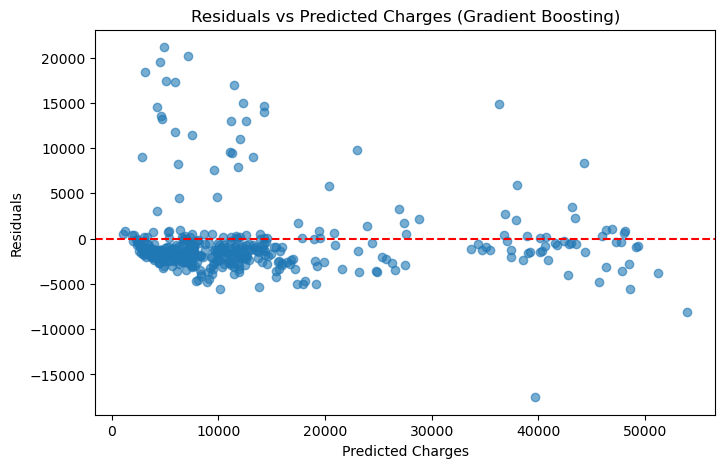

In [ ]:
residuals_gbr = y_test - gbr.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(gbr.predict(X_test), residuals_gbr, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Charges (Gradient Boosting)")
plt.show()

In [ ]:
'''In contrast to the previous models, the residual plot for the Gradient Boosting model shows a much tighter clustering of residuals around zero, with far less systematic structure. This suggests that the model more effectively captures the complex and nonlinear drivers of insurance cost variation. Both the R^2 and adjusted R^2 values improved and became more balanced between training and testing data, reflecting strong and stable generalization rather than overfitting. While a small number of outliers remain, the overall error distribution is noticeably more stable and uniform. Moreover, the feature importance results reinforce key insights: smoker status is by far the strongest predictor of insurance cost, and its effect grows nonlinearly when combined with BMI and age, indicating that lifestyle and health risk factors compound rather than act independently. Altogether, the Gradient Boosting model delivers both improved predictive performance and clearer understanding of how specific variables influence insurance charges.'''

'In contrast to the previous models, the residual plot for the Gradient Boosting model shows a much tighter clustering of residuals around zero, with far less systematic structure. This suggests that the model more effectively captures the complex and nonlinear drivers of insurance cost variation. Both the R^2 and adjusted R^2 values improved and became more balanced between training and testing data, reflecting strong and stable generalization rather than overfitting. While a small number of outliers remain, the overall error distribution is noticeably more stable and uniform. Moreover, the feature importance results reinforce key insights: smoker status is by far the strongest predictor of insurance cost, and its effect grows nonlinearly when combined with BMI and age, indicating that lifestyle and health risk factors compound rather than act independently. Altogether, the Gradient Boosting model delivers both improved predictive performance and clearer understanding of how specific 

In [ ]:
model_results = [
    {"Model": "Linear Regression", "Train R²": 0.731, "Test R²": 0.791, "Train Adj R²": 0.729, "Test Adj R²": 0.786},
    {"Model": "Polynomial Regression", "Train R²": 0.830, "Test R²": 0.869, "Train Adj R²": 0.824, "Test Adj R²": 0.856},
    {"Model": "Gradient Boosting", "Train R²": 0.900, "Test R²": 0.885, "Train Adj R²": 0.896, "Test Adj R²": 0.874}]

comparison_df = pd.DataFrame(model_results)
print(comparison_df)

                   Model  Train R²  Test R²  Train Adj R²  Test Adj R²
0      Linear Regression     0.731    0.791         0.729        0.786
1  Polynomial Regression     0.830    0.869         0.824        0.856
2      Gradient Boosting     0.900    0.885         0.896        0.874


In [ ]:
'''Across all three models, there is a consistent improvement in performance as additional complexity is introduced. The baseline linear regression model provided an initial understanding of how features relate to insurance charges, achieving a test R^2 of 0.79. Expanding the model with polynomial interaction terms increased the test R^2 to 0.87, reflecting the importance of capturing combined effects such as BMI with smoker status and age with smoker status. The strongest performance came from the Gradient Boosting model, which achieved balanced and stable train and test scores of approximately 0.90 and 0.89, indicating strong generalization without signs of overfitting.'''

'Across all three models, there is a consistent improvement in performance as additional complexity is introduced. The baseline linear regression model provided an initial understanding of how features relate to insurance charges, achieving a test R^2 of 0.79. Expanding the model with polynomial interaction terms increased the test R^2 to 0.87, reflecting the importance of capturing combined effects such as BMI with smoker status and age with smoker status. The strongest performance came from the Gradient Boosting model, which achieved balanced and stable train and test scores of approximately 0.90 and 0.89, indicating strong generalization without signs of overfitting.'

In [ ]:
'''The feature importance results from both the polynomial and Gradient Boosting models reveal how smoking status is the dominant driver of insurance costs by a significant margin, and its effect increases sharply when combined with high BMI and advancing age. These nonlinear risk interactions align with real world health cost dynamics, where lifestyle factors and age related health risk compound rather than act independently. BMI and age follow as the next most influential predictors, while the number of children and regional location have smaller but still interpretable effects.'''

'The feature importance results from both the polynomial and Gradient Boosting models reveal how smoking status is the dominant driver of insurance costs by a significant margin, and its effect increases sharply when combined with high BMI and advancing age. These nonlinear risk interactions align with real world health cost dynamics, where lifestyle factors and age related health risk compound rather than act independently. BMI and age follow as the next most influential predictors, while the number of children and regional location have smaller but still interpretable effects.'

In [ ]:
'''Overall, this project demonstrates how model choice and feature interaction modeling meaningfully affect predictive performance and insight. Beginning from a simple linear framework and progressing to more flexible models allowed for both stronger predictive accuracy and a clearer understanding of which factors drive high medical costs. Future steps could involve incorporating additional health or socioeconomic features, exploring partial dependence plots to visualize nonlinear effects, or deploying the final model as a cost estimation tool in a real world decision interface.'''

'Overall, this project demonstrates how model choice and feature interaction modeling meaningfully affect predictive performance and insight. Beginning from a simple linear framework and progressing to more flexible models allowed for both stronger predictive accuracy and a clearer understanding of which factors drive high medical costs. Future steps could involve incorporating additional health or socioeconomic features, exploring partial dependence plots to visualize nonlinear effects, or deploying the final model as a cost estimation tool in a real world decision interface.'